In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("./data/wine_train.csv")
data

,와인_종류,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
0,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
1,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450
2,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
3,2,13.86,1.51,2.67,25.0,86,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410
4,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
102,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
103,1,13.51,1.80,2.65,19.0,110,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095
104,2,12.70,3.87,2.40,23.0,101,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463


In [3]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   와인_종류                   106 non-null    int64  
 1   알코올_도수                  106 non-null    float64
 2   사과산_함량                  106 non-null    float64
 3   재_함량                    106 non-null    float64
 4   재의_알칼리도                 106 non-null    float64
 5   마그네슘_함량                 106 non-null    int64  
 6   총_페놀_함량                 106 non-null    float64
 7   플라보노이드_함량               106 non-null    float64
 8   비플라보노이드_페놀_함량           106 non-null    float64
 9   프로안토시아닌_함량              106 non-null    float64
 10  색_강도                    106 non-null    float64
 11  색조                      106 non-null    float64
 12  희석_와인의_투과율_OD280_OD315  106 non-null    float64
 13  프롤린_함량                  106 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 11.

<Axes: >

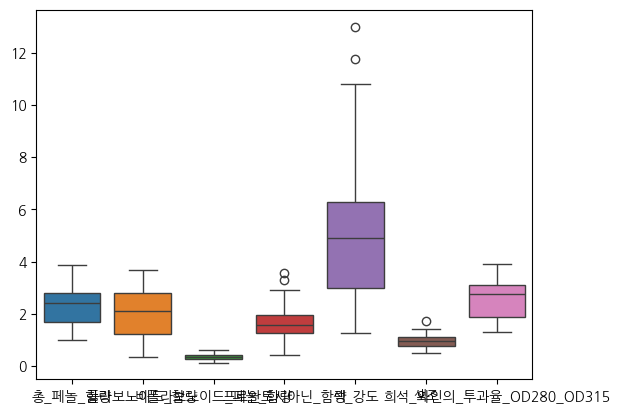

In [5]:
sns.boxplot(data.iloc[:,6:-1])

In [6]:
X = data.drop('와인_종류', axis=1)
y = data['와인_종류']

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [8]:
from sklearn.preprocessing import MinMaxScaler

In [9]:
mms = MinMaxScaler()
X_train_temp = mms.fit_transform(X_train)
X_test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(X_train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(X_test_temp, columns=X_test.columns, index=X_test.index)

# mms 변수에 있는 MinMaxScaler 가중치 저장
# joblib
* joblib.dump(경로, 파일명)
* joblib.load(경로, 파일명)

In [18]:
import joblib

In [19]:
joblib.dump(mms, "./model/MinMax_info.joblib")

['./model/MinMax_info.joblib']

In [10]:
mms_X_train

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
79,0.700000,0.479508,0.634409,0.573171,0.294872,0.223077,0.021875,0.74,0.132867,0.392491,0.390244,0.189189,0.324980
54,0.297368,0.141393,0.510753,0.743902,0.076923,0.203846,0.375000,0.60,0.398601,0.099829,0.691057,0.359073,0.175424
98,0.755263,0.155738,0.408602,0.329268,0.217949,0.711538,0.906250,0.16,0.601399,0.411263,0.349593,0.772201,0.571544
20,0.207895,0.163934,0.279570,0.542683,0.025641,0.480769,0.359375,0.48,0.349650,0.066553,0.373984,0.428571,0.110752
92,0.823684,0.325820,0.602151,0.573171,0.089744,0.165385,0.065625,0.62,0.286713,0.718430,0.113821,0.146718,0.308812
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,0.744737,0.088115,0.489247,0.329268,0.179487,0.665385,0.831250,0.18,0.500000,0.506826,0.430894,0.857143,0.620049
16,0.413158,0.086066,0.290323,0.481707,0.051282,0.076923,0.271875,0.32,0.325175,0.099829,0.455285,0.555985,0.229588
59,0.484211,0.756148,0.602151,0.664634,0.025641,0.173077,0.050000,0.68,0.153846,0.543515,0.048780,0.204633,0.280517
37,0.000000,0.120902,0.451613,0.664634,0.012821,0.465385,0.525000,0.78,0.555944,0.052901,1.000000,0.594595,0.104285


In [11]:
mms_X_test

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
61,0.486842,0.424180,0.559140,0.573171,0.256410,0.019231,0.228125,0.22,0.143357,0.351536,0.211382,0.034749,0.203719
63,0.331579,0.141393,0.456989,0.597561,0.243590,-0.057692,0.165625,0.48,0.363636,0.151024,0.346341,0.189189,0.478577
3,0.744737,0.120902,0.704301,0.878049,0.025641,0.653846,0.740625,0.16,0.506993,0.179181,0.715447,0.706564,0.106710
40,0.331579,0.461066,0.456989,0.451220,0.051282,0.615385,0.781250,0.64,0.835664,0.087031,0.764228,0.579151,0.103476
97,0.750000,0.844262,0.467742,0.573171,-0.051282,-0.103846,-0.046875,0.54,0.090909,0.308874,0.081301,0.000000,0.110752
81,0.439474,0.538934,0.537634,0.664634,0.282051,0.173077,0.221875,0.08,0.146853,0.317406,0.243902,-0.015444,0.260307
78,0.650000,0.450820,0.677419,0.817073,0.500000,0.057692,0.337500,0.18,0.290210,0.624573,0.089431,-0.011583,0.179466
95,0.276316,0.186475,0.516129,0.481707,-0.038462,0.134615,0.315625,0.78,0.426573,0.095563,0.487805,0.362934,0.163298
65,0.613158,0.336066,0.532258,0.573171,0.064103,0.057692,0.003125,0.48,0.076923,0.368601,0.178862,0.440154,0.405821
57,0.721053,0.200820,0.709677,0.396341,0.397436,0.673077,0.718750,0.52,0.440559,0.428328,0.528455,0.617761,0.886823


In [12]:
y_train.value_counts()

와인_종류
2    29
1    25
3    20
Name: count, dtype: int64

In [13]:
y_train = pd.get_dummies(y_train)
y_train

,1,2,3
79,False,False,True
54,False,True,False
98,True,False,False
20,False,True,False
92,False,False,True
...,...,...,...
43,True,False,False
16,False,True,False
59,False,False,True
37,False,True,False


In [14]:
y_test = pd.get_dummies(y_test)
y_test

,1,2,3
61,False,False,True
63,False,True,False
3,False,True,False
40,False,True,False
97,False,False,True
81,False,False,True
78,False,False,True
95,False,True,False
65,False,False,True
57,True,False,False


In [15]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

2025-05-15 16:40:45.169507: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 16:40:45.791545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747294845.997922     636 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747294846.073492     636 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747294846.563137     636 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [16]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))
model.summary()

I0000 00:00:1747294860.328155     636 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,555 (13.89 KB)

 Trainable params: 3,555 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000


I0000 00:00:1747295281.242040     685 service.cc:152] XLA service 0x7f6b60009170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747295281.242141     685 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-15 16:48:01.353664: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747295281.774176     685 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/5 ━━━━━━━━━━━━━━━━━━━━ 26s 7s/step - accuracy: 0.5000 - loss: 1.0061

I0000 00:00:1747295285.435314     685 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3826 - loss: 1.0610 - val_accuracy: 0.3125 - val_loss: 1.0692
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3244 - loss: 1.0223 - val_accuracy: 0.3125 - val_loss: 1.0185
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3836 - loss: 0.9507 - val_accuracy: 0.3438 - val_loss: 0.9792
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4346 - loss: 0.9504 - val_accuracy: 0.5000 - val_loss: 0.9460
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6166 - loss: 0.8830 - val_accuracy: 0.5312 - val_loss: 0.9136
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ -1s -152895us/step - accuracy: 0.6123 - loss: 0.8746 - val_accuracy: 0.5938 - val_loss: 0.8798
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5791 - loss: 0.8788 - val_accuracy: 0.6562 - val_loss: 0.8426
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6740 - loss: 0.8181 - val_accuracy: 0.6875 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0242 - val_accuracy: 0.9375 - val_loss: 0.1056
Epoch 52/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 0.0247 - val_accuracy: 0.9375 - val_loss: 0.0990
Epoch 53/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0309 - val_accuracy: 0.9375 - val_loss: 0.1042
Epoch 54/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.0265 - val_accuracy: 0.9375 - val_loss: 0.1002
Epoch 55/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.9688 - val_loss: 0.0910
Epoch 56/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.9688 - val_loss: 0.0889
Epoch 57/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0247 - val_accuracy: 0.9375 - val_loss: 0.0996
Epoch 58/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0213 - val_accuracy: 0.9375 - val_los

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9375 - val_loss: 0.0950
Epoch 102/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.9375 - val_loss: 0.0944
Epoch 103/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.9375 - val_loss: 0.0918
Epoch 104/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9375 - val_loss: 0.0924
Epoch 105/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9375 - val_loss: 0.0918
Epoch 106/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.9375 - val_loss: 0.0921
Epoch 107/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9375 - val_loss: 0.0954
Epoch 108/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9375 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9375 - val_loss: 0.1017
Epoch 152/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9375 - val_loss: 0.1016
Epoch 153/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9375 - val_loss: 0.1009
Epoch 154/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9375 - val_loss: 0.1022
Epoch 155/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9375 - val_loss: 0.1030
Epoch 156/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9375 - val_loss: 0.1029


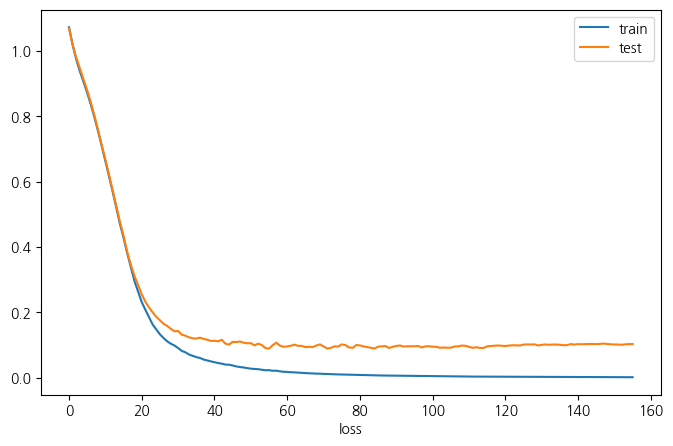

In [17]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=100)
# file_path = "./model/wine_{val_loss:.4f}_epoch_{epoch:04d}.keras"
file_path = "./model/wine_best_model.keras"
model_save = ModelCheckpoint(filepath=file_path, save_best_only=True)
history = model.fit(mms_X_train, y_train,
                   epochs=1000,
                   batch_size=16,
                   validation_data=(mms_X_test, y_test),
                   callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.xlabel("loss")
plt.legend(['train', 'test'])
plt.show()

# 